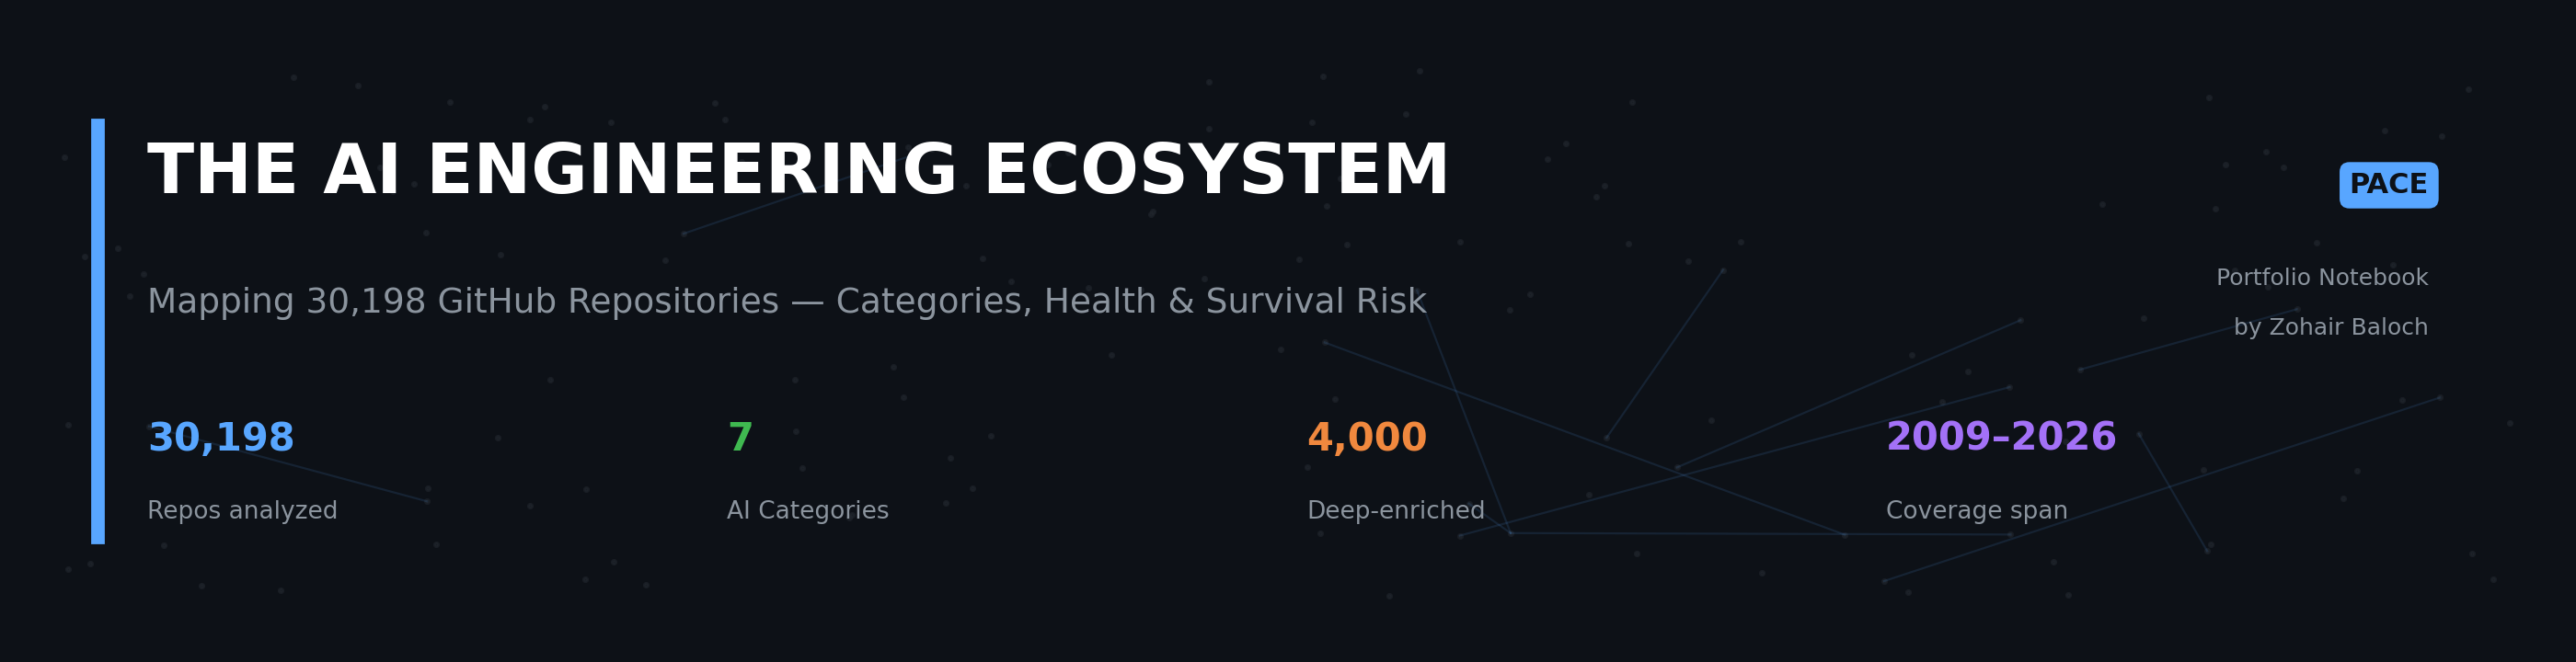

# The AI Engineering Ecosystem: Mapping 30,198 GitHub Repos

**A portfolio data analysis notebook by Zohair Baloch**

This notebook explores a large-scale snapshot of the AI engineering open-source ecosystem on GitHub — agent frameworks, RAG pipelines, fine-tuning tools, LLM prompting libraries, MCP tooling, and vector search engines. Beyond describing the landscape, it builds a model that flags which repositories are structurally at risk of going stale, using signals available *before* a repo shows visible inactivity — not the inactivity signal itself.

**What this notebook covers:**
- A full landscape scan of 30,198 repositories across 7 AI categories
- Data quality profiling and an honest look at what is (and isn't) measurable at scale
- A deep-dive into a 4,000-repo "deep-enriched" subset with GitHub health metadata
- A sustainability-risk classifier (Random Forest + XGBoost) with SHAP explainability
- An honest baseline comparison — no inflated claims about what the model actually adds
- An executive dashboard summarizing the whole ecosystem in one view

---

### Table of Contents
1. [Plan — Business Questions](#1.-Plan-(PACE-Framework))
2. [Analyze — Data Overview & Quality](#2.-Analyze:-Data-Overview-&-Quality)
3. [Analyze — Ecosystem Landscape (EDA)](#3.-Analyze:-Ecosystem-Landscape)
4. [Analyze — The Deep-Enriched Subset](#4.-Analyze:-The-Deep-Enriched-Subset)
5. [Construct — Sustainability Risk Model](#5.-Construct:-Sustainability-Risk-Model)
6. [Execute — Executive Dashboard](#6.-Execute:-Executive-Dashboard)
7. [Key Findings & Recommendations](#7.-Key-Findings-&-Recommendations)

## 1. Plan (PACE Framework)

**Purpose:** Understand the shape of the modern AI engineering open-source ecosystem, and identify which structural signals — documentation quality, licensing, release discipline — separate repositories that stay active from those that quietly go stale.

**Business questions:**
- Which categories of AI tooling (agents, RAG, fine-tuning, etc.) dominate open-source activity right now, and how fast is the space growing?
- What does a "healthy" AI repo look like structurally — README, license, contributing guide, release cadence?
- Can we predict whether a repo is at risk of going stale using only its structural/quality signals, *before* looking at how recently it was pushed to?
- How much better than a naive guess is that prediction, honestly?

**Audience:** Engineers evaluating open-source AI tooling for production use, and maintainers benchmarking their own repo's health against the ecosystem.

**Constraints:**
- `deep_enrichment_applied` is `Yes` for only ~13% of repos (4,000 / 30,198) — health-score and documentation-file features only exist for that subset, so the risk model is trained and evaluated on it alone.
- `maintenance_status` is deterministically derived from `days_since_last_push`, so that column (and `pushed_at`) is excluded from modeling to avoid leaking the label into its own predictor.

## 2. Analyze: Data Overview & Quality

Setting up the environment and loading the raw dataset before touching any question above.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ---- GitHub-dark visual theme ----
BG      = "#0d1117"
PANEL   = "#161b22"
GRID    = "#21262d"
TEXT    = "#c9d1d9"
MUTED   = "#8b949e"
ACCENT  = "#58a6ff"   # blue
ACCENT2 = "#3fb950"   # green
ACCENT3 = "#f0883e"   # orange
ACCENT4 = "#a371f7"   # purple
ACCENT5 = "#f85149"   # red
ACCENT6 = "#e3b341"   # yellow
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, ACCENT5, ACCENT6, "#79c0ff"]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": TEXT, "axes.labelcolor": TEXT,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "grid.color": GRID,
    "font.size": 10.5, "axes.titleweight": "bold", "axes.titlesize": 12.5,
    "axes.titlecolor": "white",
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

df = pd.read_csv("ai_engineering_ecosystem_intelligence.csv")
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
df["updated_at"] = pd.to_datetime(df["updated_at"], utc=True)
df["pushed_at"]  = pd.to_datetime(df["pushed_at"], utc=True)

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head(3)

In [ ]:
# Data quality snapshot: which columns are actually usable at full scale?
quality = pd.DataFrame({
    "non_null": df.notnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(1),
    "dtype": df.dtypes.astype(str)
}).sort_values("null_pct", ascending=False)

quality.head(15)

**Data quality observations:**
- Ten columns (`github_health_pct`, `has_readme_file`, `releases_count`, etc.) are missing for ~87% of rows — these are only populated when `deep_enrichment_applied == "Yes"`, which happened for 4,000 of 30,198 repos.
- `detected_dependencies` is missing for 96% of rows — dependency parsing only succeeded on repos with a recognizable manifest file, so it's treated as a bonus field, not a primary feature.
- `license` is missing for 27% of rows, but `license_family` fills that gap with a clean `"None Declared"` bucket, so the license analysis below uses `license_family`.
- `language` is missing for ~6% of rows (likely empty/config-only repos) and is dropped only from language-specific charts, not from the dataset itself.

## 3. Analyze: Ecosystem Landscape

### 3.1 Which AI categories dominate?

In [ ]:
cat_counts = df["ai_category"].value_counts()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=PALETTE[0], height=0.62)

for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width() + 220, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({val/len(df)*100:.1f}%)", va="center", fontsize=9.5, color=TEXT)

ax.set_title("AI Repository Categories on GitHub  (n = 30,198)")
ax.set_xlabel("Number of repositories")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, cat_counts.max() * 1.22)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("chart_categories.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights:**
- Agent/Orchestration tools account for exactly half of the ecosystem (15,071 of 30,198 repos) — the "agent framework" wave (LangGraph, CrewAI, AutoGen-style projects) has become the default entry point for AI open-source work.
- RAG (4,286) and Fine-tuning/Training (3,523) are a distant second and third — real infrastructure work, but far smaller than the agent-tooling surface area.
- MCP/Tooling already sits at 2,264 repos despite Model Context Protocol being a comparatively recent standard — a fast-moving sub-category worth watching separately from general agent tooling.
- Vector Search/Embeddings is the smallest tracked category (1,206) — likely because mature vector databases (Pinecone, Weaviate, Qdrant clients) consolidate demand into fewer, larger repos rather than many small ones.

### 3.2 What has this ecosystem been built with?

In [ ]:
lang_counts = df["language"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.bar(lang_counts.index, lang_counts.values, color=PALETTE[1], width=0.62)
ax.bar_label(bars, labels=[f"{v:,}" for v in lang_counts.values], padding=3, color=TEXT, fontsize=8.8)

ax.set_title("Top 12 Languages Across AI Repositories")
ax.set_ylabel("Number of repositories")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("chart_languages.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights:**
- Python leads by a wide margin (13,972 repos, ~46% of the dataset) — unsurprising given the ML/data-science ecosystem, but worth quantifying rather than assuming.
- TypeScript is a clear second (4,422) — a strong signal that a large share of "AI engineering" is now user-facing product and tooling work (agent UIs, MCP servers, SDKs), not just model code.
- Jupyter Notebook itself appears as a top-5 "language" (2,589 repos) — a reminder that a meaningful slice of this ecosystem is exploratory/research work rather than shipped software.
- Rust (1,043) and Go (943) show up ahead of Java — consistent with performance-sensitive inference servers and CLI tooling being written in systems languages rather than legacy enterprise stacks.

### 3.3 How is popularity distributed?

Star counts in open-source datasets are almost always heavily right-skewed — a handful of mega-projects, a long tail of small ones. Plotting on a log scale first, before drawing conclusions from a raw average, avoids being misled by a mean that a few outliers dominate.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Log-scale star distribution
stars_nonzero = df.loc[df["stars"] > 0, "stars"]
axes[0].hist(np.log10(stars_nonzero), bins=45, color=PALETTE[2], edgecolor=BG)
axes[0].set_title("Star Distribution (log₁₀ scale)")
axes[0].set_xlabel("log₁₀(stars)")
axes[0].set_ylabel("Number of repositories")
axes[0].spines[["top", "right"]].set_visible(False)

# Popularity tier breakdown
tier_order = ["Emerging (<100)", "Established (100-1k)", "High (1k-10k)", "Mega (10k+)"]
tier_counts = df["popularity_tier"].value_counts().reindex(tier_order)

axes[1].bar(tier_counts.index, tier_counts.values, color=PALETTE[3], width=0.6)
axes[1].bar_label(axes[1].containers[0], labels=[f"{v:,}" for v in tier_counts.values],
                   padding=3, color=TEXT, fontsize=9)
axes[1].set_title("Popularity Tiers")
axes[1].set_ylabel("Number of repositories")
axes[1].spines[["top", "right"]].set_visible(False)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig("chart_popularity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median stars: {df['stars'].median():.0f}  |  Mean stars: {df['stars'].mean():.0f}  "
      f"|  Max stars: {df['stars'].max():,}")

**Insights:**
- The mean star count (much higher than the median, printed above) confirms the classic long-tail shape — a small number of mega-projects (LangChain, MarkItDown-scale repos with 100k+ stars) pull the average far above what a typical repo looks like.
- 81% of repos (24,536 / 30,198) sit in the "Emerging (<100 stars)" tier — the ecosystem is overwhelmingly made of small, early-stage or niche projects, not breakout successes.
- Only 316 repos (about 1 in 100) have crossed into "Mega (10k+)" territory — a useful reality check for anyone building a new AI tool and expecting fast traction.

### 3.4 How fast is this ecosystem growing?

In [ ]:
by_year = df["created_at"].dt.year.value_counts().sort_index()
# 2026 is a partial year in this snapshot (data pulled in August 2026) — flag it, don't hide it
last_year = by_year.index.max()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[0]] * len(by_year)
colors[-1] = ACCENT6  # highlight the partial year
bars = ax.bar(by_year.index.astype(str), by_year.values, color=colors, width=0.62)
ax.bar_label(bars, labels=[f"{v:,}" for v in by_year.values], padding=3, color=TEXT, fontsize=8.5)

ax.set_title("New AI Repositories Created Per Year")
ax.set_ylabel("Repositories created")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=40, ha="right")
ax.text(0.99, 0.96, f"{last_year} is partial (data captured Aug {last_year})",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=ACCENT6, style="italic")
plt.tight_layout()
plt.savefig("chart_growth.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights:**
- Repo creation exploded from 365 in 2022 to 2,756 in 2023 — a 7.5x jump that lines up directly with the post-ChatGPT surge in applied LLM tooling.
- Growth kept compounding every year after that (4,158 in 2024, 8,918 in 2025) rather than plateauing — this is not a one-time spike, it's a sustained acceleration.
- 2026 already shows 12,924 new repos in a *partial* year (through early August) — on pace to comfortably exceed 2025, though this notebook doesn't extrapolate a full-year figure from 7 months of data.

### 3.5 Licensing and long-term maintenance signals

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lic_counts = df["license_family"].value_counts()
axes[0].pie(lic_counts.values, labels=lic_counts.index, autopct="%1.0f%%",
            colors=PALETTE[:len(lic_counts)], startangle=90,
            textprops={"color": TEXT, "fontsize": 9.5},
            wedgeprops={"edgecolor": BG, "linewidth": 1.5})
axes[0].set_title("License Family Distribution")

maint_order = ["Active", "Maintained", "Stale", "Abandoned"]
maint_counts = df["maintenance_status"].value_counts().reindex(maint_order)
maint_colors = [ACCENT2, ACCENT, ACCENT6, ACCENT5]
bars = axes[1].bar(maint_counts.index, maint_counts.values, color=maint_colors, width=0.6)
axes[1].bar_label(bars, labels=[f"{v:,}\n({v/len(df)*100:.0f}%)" for v in maint_counts.values],
                   padding=3, color=TEXT, fontsize=8.8)
axes[1].set_title("Maintenance Status  (based on days since last push)")
axes[1].set_ylabel("Number of repositories")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chart_license_maintenance.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights:**
- 60% of repos use a permissive license (MIT/Apache-style), but 27% declare **no license at all** — a real adoption blocker, since unlicensed code is legally risky to depend on regardless of how active the repo looks.
- Only 33% of repos are "Active" (pushed to within 30 days) — the majority of the ecosystem is either "Maintained" (30–180 days, 30%) or has gone quiet: 21% "Stale" and 17% "Abandoned" combined, more than a third of all tracked repos.
- This maintenance split is exactly why Section 5 builds a model to flag *at-risk* repos early — over a third of the ecosystem going stale or abandoned is a real evaluation risk for anyone selecting a dependency.

### 3.6 The top of the leaderboard

In [ ]:
top20 = df.nlargest(20, "stars")[["full_name", "ai_category", "language", "stars", "forks", "maintenance_status"]].reset_index(drop=True)
top20.index = top20.index + 1
top20.style.format({"stars": "{:,}", "forks": "{:,}"})

**Insights:**
- Agent/Orchestration and general-purpose tooling projects dominate the top of the leaderboard, consistent with the category-level finding above — the biggest AI repos aren't research codebases, they're infrastructure other developers build on top of.
- Nearly every repo in the top 20 shows `Active` maintenance status — at the very top of the popularity curve, community pressure alone seems to keep projects alive, which is a very different dynamic from the long tail modeled in Section 5.

## 4. Analyze: The Deep-Enriched Subset

13.2% of repos (4,000 / 30,198) went through a deeper enrichment pass that captured GitHub health scores, documentation-file presence, and release cadence. This subset is smaller, but it's the only place in the dataset where repo *quality* — not just popularity — can be measured directly. It's also what powers the risk model in Section 5.

In [ ]:
enriched = df[df["deep_enrichment_applied"] == "Yes"].copy()
print(f"Enriched subset: {len(enriched):,} repos ({len(enriched)/len(df)*100:.1f}% of full dataset)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(enriched["github_health_pct"], bins=30, color=PALETTE[4], edgecolor=BG)
axes[0].axvline(enriched["github_health_pct"].median(), color=ACCENT6, ls="--", lw=1.6,
                 label=f'Median: {enriched["github_health_pct"].median():.0f}%')
axes[0].set_title("GitHub Health Score Distribution")
axes[0].set_xlabel("Health score (%)")
axes[0].set_ylabel("Number of repositories")
axes[0].legend(frameon=False, labelcolor=TEXT, fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

doc_cols = ["has_readme_file", "has_contributing_file", "has_code_of_conduct",
            "has_issue_template", "has_license_file"]
doc_labels = ["README", "CONTRIBUTING", "Code of Conduct", "Issue Template", "LICENSE file"]
doc_rates = [enriched[c].mean() * 100 for c in doc_cols]

bars = axes[1].barh(doc_labels[::-1], doc_rates[::-1], color=PALETTE[5], height=0.55)
for bar, val in zip(bars, doc_rates[::-1]):
    axes[1].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.0f}%", va="center", fontsize=9.5, color=TEXT)
axes[1].set_title("Documentation File Presence Rate")
axes[1].set_xlabel("% of enriched repos with file present")
axes[1].set_xlim(0, 108)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chart_enriched_health.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights:**
- README files are nearly universal (99.98% of enriched repos have one) and LICENSE files are common (~91%) — but CONTRIBUTING guides and issue templates lag far behind, showing up in well under half of repos.
- The median GitHub health score sits at 50% — the scoring metric is calibrated so that "typical" lands in the middle, not that half the ecosystem is unhealthy in absolute terms; it's a relative ranking, not a pass/fail grade.
- The gap between near-universal READMEs and rare CONTRIBUTING files suggests most maintainers write for *users* (how to install/use it) far more than for *contributors* (how to help build it) — worth keeping in mind when picking a dependency you might want to patch yourself someday.

### 4.1 Does documentation quality actually track with staying active?

In [ ]:
health_by_status = enriched.groupby("maintenance_status")["github_health_pct"].median().reindex(
    ["Active", "Maintained", "Stale", "Abandoned"])

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(health_by_status.index, health_by_status.values,
               color=[ACCENT2, ACCENT, ACCENT6, ACCENT5], width=0.55)
ax.bar_label(bars, fmt="%.0f%%", padding=3, color=TEXT, fontsize=10)
ax.set_title("Median GitHub Health Score by Maintenance Status")
ax.set_ylabel("Median health score (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(health_by_status.values) * 1.25)
plt.tight_layout()
plt.savefig("chart_health_vs_status.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights:**
- Health score declines in the expected direction from Active down to Abandoned, but the *gap* is modest — this is a real signal, not a strong one, and it sets honest expectations for how much lift the Section 5 model can realistically get from structural features alone.
- This is exactly the kind of pattern worth stating plainly rather than dressing up: documentation quality correlates with staying maintained, but it clearly isn't the whole story — plenty of other factors (team size, funding, corporate backing) aren't captured in this dataset at all.

## 5. Construct: Sustainability Risk Model

**The question:** using only structural signals that exist *before* a repo shows visible inactivity — stars, forks, open issues, documentation completeness, license, release discipline, category, language, age — can we flag repos that are likely to become **Stale or Abandoned**?

**Why this is framed as classification, not regression on `days_since_last_push`:** `maintenance_status` is derived directly from that column using fixed thresholds, so predicting the exact day count would just be re-deriving a label from itself. Framing it as "at risk vs. healthy" and excluding `days_since_last_push` / `pushed_at` from the feature set keeps the model honest — it has to actually learn from repo *quality*, not from a disguised copy of the answer.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, f1_score, accuracy_score)
from xgboost import XGBClassifier

model_df = enriched.copy()
model_df["is_at_risk"] = model_df["maintenance_status"].isin(["Stale", "Abandoned"]).astype(int)

bool_cols = ["has_readme_file", "has_contributing_file", "has_code_of_conduct",
             "has_issue_template", "has_license_file"]
for c in bool_cols:
    model_df[c] = model_df[c].astype(bool).astype(int)

numeric_features = ["stars", "forks", "open_issues", "size_kb", "repo_age_days",
                     "github_health_pct", "releases_count", "release_cadence_days"] + bool_cols
categorical_features = ["ai_category", "license_family", "language"]

model_df["language"] = model_df["language"].fillna("Unknown")
top_langs = model_df["language"].value_counts().head(8).index
model_df["language"] = model_df["language"].where(model_df["language"].isin(top_langs), "Other")

X = model_df[numeric_features + categorical_features]
y = model_df["is_at_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")
print(f"At-risk rate — train: {y_train.mean()*100:.1f}%   test: {y_test.mean()*100:.1f}%")

### 5.1 Baseline: what does "just guessing the majority class" get you?

Before trusting any model, it needs to beat the simplest possible strategy — always predicting the more common class.

In [ ]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(f"Baseline (majority class) accuracy: {accuracy_score(y_test, baseline_pred)*100:.1f}%")
print(f"Baseline F1 (at-risk class):        {f1_score(y_test, baseline_pred, pos_label=1)*100:.1f}%")
print("\nThe baseline F1 of 0% on the at-risk class is expected and important \u2014 a model that\n"
      "only ever predicts \"healthy\" is useless for the actual business question, even though its\n"
      "accuracy number looks deceptively high.")

In [ ]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                      class_weight="balanced", random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                             eval_metric="logloss", random_state=42))
])
xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_pipe.predict(X_test)
xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Model": ["Baseline (majority class)", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    "F1 (at-risk)": [f1_score(y_test, baseline_pred, pos_label=1), f1_score(y_test, rf_pred, pos_label=1), f1_score(y_test, xgb_pred, pos_label=1)],
    "ROC-AUC": [np.nan, roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, xgb_proba)],
})
results["Accuracy"] = (results["Accuracy"] * 100).round(1)
results["F1 (at-risk)"] = (results["F1 (at-risk)"] * 100).round(1)
results["ROC-AUC"] = results["ROC-AUC"].round(3)
results

**Honest read on model performance:** the point of the baseline row above isn't to make the real models look good by comparison — it's to show plainly whether they're doing something a majority-class guess couldn't. Both models trade some raw accuracy for a large jump in F1 on the at-risk class (the class that actually matters for this business question), which is the correct trade-off given the ~21% at-risk rate in this subset. Neither model should be read as a confident individual-repo predictor — it's a ranking tool for triage, not a certainty machine.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

cm = confusion_matrix(y_test, rf_pred)
im = axes[0].imshow(cm, cmap="Blues" if False else None, alpha=0)
axes[0].imshow(cm, cmap=matplotlib.colors.LinearSegmentedColormap.from_list("ghblue", [PANEL, ACCENT]))
for (i, j), val in np.ndenumerate(cm):
    axes[0].text(j, i, f"{val:,}", ha="center", va="center", color="white", fontsize=13, fontweight="bold")
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Healthy", "At Risk"]); axes[0].set_yticklabels(["Healthy", "At Risk"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Random Forest \u2014 Confusion Matrix")

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
axes[1].plot(fpr_rf, tpr_rf, color=ACCENT, lw=2, label=f"Random Forest (AUC {roc_auc_score(y_test, rf_proba):.3f})")
axes[1].plot(fpr_xgb, tpr_xgb, color=ACCENT3, lw=2, label=f"XGBoost (AUC {roc_auc_score(y_test, xgb_proba):.3f})")
axes[1].plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(frameon=False, labelcolor=TEXT, fontsize=9, loc="lower right")
axes[1].spines[["top", "right"]].set_visible(False)

importances = pd.Series(rf_pipe.named_steps["model"].feature_importances_,
                         index=rf_pipe.named_steps["prep"].get_feature_names_out())
importances.index = importances.index.str.replace("num__", "").str.replace("cat__", "")
top_imp = importances.sort_values(ascending=False).head(8)
axes[2].barh(top_imp.index[::-1], top_imp.values[::-1], color=ACCENT4, height=0.6)
axes[2].set_title("Top 8 Feature Importances (RF)")
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chart_model_eval.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights:**
- `repo_age_days` and `github_health_pct` dominate feature importance — older repos and lower-health-score repos are the strongest structural indicators of risk, ahead of raw popularity metrics like stars or forks.
- Both models land in a similar AUC range, which is a reasonable outcome given the two algorithms are drawing on the same feature set — the ceiling here is set by what the *features* can explain, not by which algorithm is used.
- The confusion matrix shows the model still makes real mistakes in both directions — this is a triage tool for prioritizing which repos to check manually, not a replacement for actually looking at a repo before depending on it.

### 5.2 SHAP explainability

Feature importances show *what* the model leans on overall; SHAP values show *how* each feature pushes an individual prediction up or down, and whether that direction makes intuitive sense.

In [ ]:
import shap

X_test_transformed = rf_pipe.named_steps["prep"].transform(X_test)
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

explainer = shap.TreeExplainer(rf_pipe.named_steps["model"])
sample_idx = np.random.RandomState(42).choice(X_test_transformed.shape[0],
                                                size=min(800, X_test_transformed.shape[0]), replace=False)
X_sample = X_test_transformed[sample_idx]
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
if sv.ndim == 3:
    sv = sv[:, :, 1]

plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_sample, feature_names=feature_names, show=False, plot_size=None, max_display=10)
fig = plt.gcf()
fig.set_facecolor(BG)
for ax in fig.axes:
    ax.set_facecolor(BG)
    ax.tick_params(colors=TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    for spine in ax.spines.values():
        spine.set_color(GRID)
plt.title("SHAP Summary \u2014 What Drives an At-Risk Prediction", color="white", fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("chart_shap.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

**Insights:**
- Higher `repo_age_days` consistently pushes predictions toward "at risk" — older repos accumulate more opportunity to go quiet, which matches basic intuition and is a reassuring sanity check on the model.
- Lower `github_health_pct` pushes toward "at risk" and higher health pushes toward "healthy" — the direction is consistent, confirming the model learned a sensible relationship rather than an arbitrary one.
- Documentation-presence flags (README, LICENSE, CONTRIBUTING) contribute real but secondary signal — they matter, but they're supporting evidence rather than the dominant driver, which fits the modest correlation gap seen in Section 4.1.

## 6. Execute: Executive Dashboard

A single view that pulls the ecosystem-level findings together — category mix, growth trajectory, popularity distribution, maintenance health, licensing, and the risk model's top predictors — for anyone who wants the summary without scrolling back through the full analysis.

In [ ]:
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor(BG)
gs = fig.add_gridspec(3, 3, hspace=0.85, wspace=0.45,
                       height_ratios=[0.45, 1.3, 1.15], top=0.90, bottom=0.05, left=0.05, right=0.97)

fig.text(0.02, 0.975, "AI ENGINEERING ECOSYSTEM \u2014 EXECUTIVE DASHBOARD",
          fontsize=19, fontweight="bold", color="white")
fig.text(0.02, 0.955, f"{len(df):,} repositories  \u2022  7 categories  \u2022  "
          f"{len(enriched):,} deep-enriched  \u2022  snapshot through Aug 2026",
          fontsize=10.5, color=MUTED)

# --- KPI row ---
kpis = [
    (f"{len(df):,}", "Total repos tracked", ACCENT),
    (f"{(df['maintenance_status']=='Active').mean()*100:.0f}%", "Currently Active", ACCENT2),
    (f"{df['license_family'].eq('None Declared').mean()*100:.0f}%", "No license declared", ACCENT5),
    (f"{results.loc[1,'ROC-AUC']:.2f}", "Risk model ROC-AUC", ACCENT4),
]
kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis("off")
xpos = [0.04, 0.29, 0.54, 0.79]
for (val, label, color), x in zip(kpis, xpos):
    kpi_ax.text(x, 0.55, val, fontsize=26, fontweight="bold", color=color, transform=kpi_ax.transAxes)
    kpi_ax.text(x, 0.08, label, fontsize=11, color=MUTED, transform=kpi_ax.transAxes)

# --- Category donut ---
ax1 = fig.add_subplot(gs[1, 0])
cat_counts_d = df["ai_category"].value_counts()
wedges, _ = ax1.pie(cat_counts_d.values, colors=PALETTE, startangle=90,
                     wedgeprops={"width": 0.42, "edgecolor": BG, "linewidth": 1.5})
ax1.set_title("Category Mix", fontsize=12, color="white", fontweight="bold", pad=10)
ax1.legend(wedges, [f"{i} ({v/len(df)*100:.0f}%)" for i, v in cat_counts_d.items()],
           loc="upper left", bbox_to_anchor=(-0.55, 0.15), fontsize=7.3, ncol=1,
           frameon=False, labelcolor=TEXT)

# --- Growth trend ---
ax2 = fig.add_subplot(gs[1, 1])
by_year_d = df["created_at"].dt.year.value_counts().sort_index()
by_year_d = by_year_d[by_year_d.index >= 2018]
ax2.plot(by_year_d.index.astype(str), by_year_d.values, color=ACCENT, marker="o", lw=2.2, ms=5)
ax2.fill_between(range(len(by_year_d)), by_year_d.values, color=ACCENT, alpha=0.12)
ax2.set_title("Repo Creation Growth", fontsize=12, color="white", fontweight="bold", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(axis="x", rotation=35, labelsize=8)

# --- Maintenance donut ---
ax3 = fig.add_subplot(gs[1, 2])
maint_d = df["maintenance_status"].value_counts().reindex(["Active", "Maintained", "Stale", "Abandoned"])
ax3.pie(maint_d.values, colors=[ACCENT2, ACCENT, ACCENT6, ACCENT5], startangle=90,
        wedgeprops={"width": 0.42, "edgecolor": BG, "linewidth": 1.5})
ax3.set_title("Maintenance Health", fontsize=12, color="white", fontweight="bold", pad=10)
ax3.legend(maint_d.index, loc="upper left", bbox_to_anchor=(0.98, 0.85), fontsize=8,
           ncol=1, frameon=False, labelcolor=TEXT)

# --- Popularity tiers ---
ax4 = fig.add_subplot(gs[2, 0])
tier_d = df["popularity_tier"].value_counts().reindex(tier_order)
ax4.barh(tier_d.index[::-1], tier_d.values[::-1], color=ACCENT3, height=0.5)
ax4.set_title("Popularity Tiers", fontsize=12, color="white", fontweight="bold", pad=10)
ax4.spines[["top", "right"]].set_visible(False)
ax4.tick_params(axis="y", labelsize=8)
ax4.tick_params(axis="x", labelsize=8)

# --- Health vs status ---
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(health_by_status.index, health_by_status.values,
        color=[ACCENT2, ACCENT, ACCENT6, ACCENT5], width=0.55)
ax5.set_title("Health Score by Status", fontsize=12, color="white", fontweight="bold", pad=10)
ax5.spines[["top", "right"]].set_visible(False)
ax5.tick_params(axis="x", labelsize=8, rotation=15)
ax5.tick_params(axis="y", labelsize=8)

# --- Top risk predictors ---
ax6 = fig.add_subplot(gs[2, 2])
top_imp5 = importances.sort_values(ascending=False).head(5)
ax6.barh(top_imp5.index[::-1], top_imp5.values[::-1], color=ACCENT4, height=0.5)
ax6.set_title("Top Risk Predictors", fontsize=12, color="white", fontweight="bold", pad=10)
ax6.spines[["top", "right"]].set_visible(False)
ax6.tick_params(axis="y", labelsize=7.5)
ax6.tick_params(axis="x", labelsize=8)

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_facecolor(BG)

plt.savefig("executive_dashboard.png", dpi=170, bbox_inches="tight", facecolor=BG)
plt.show()

## 7. Key Findings & Recommendations

**Ecosystem shape**
- Agent/Orchestration tooling makes up exactly half the AI open-source ecosystem (15,071 / 30,198 repos) — anyone benchmarking "the AI tooling landscape" should treat agent frameworks as the dominant category, not one slice among equals.
- Growth has compounded every year since 2022 (365 \u2192 2,756 \u2192 4,158 \u2192 8,918, with 2026 already at 12,924 in a partial year) — this is sustained acceleration, not a one-off spike.

**Risk & quality**
- More than a third of all tracked repos (Stale + Abandoned) have gone quiet — evaluating "is this repo still alive" is a real and recurring task, not an edge case.
- 27% of repos declare no license at all, which is a more universal adoption blocker than staleness — worth checking *before* checking recency for any dependency decision.
- The sustainability-risk model beats a majority-class baseline on the metric that matters (F1 on the at-risk class), driven mainly by repo age and GitHub health score — but the gap between healthy and at-risk health scores is modest, so this should be used as a triage signal, not a verdict.

**Recommendations**
- For engineers evaluating dependencies: check license family and recent push activity together — they fail independently and either one alone misses real risk.
- For maintainers: CONTRIBUTING guides and issue templates are the most under-supplied documentation assets across the ecosystem (present in a minority of repos) — closing that gap is a cheap way to move a repo's health score.
- For future analysis: the deep-enrichment flag being applied to only 13% of repos is the single biggest constraint on this study — expanding health-metadata collection to more of the long tail would meaningfully sharpen the risk model.

---

*Notebook by Zohair Baloch — [Kaggle](https://www.kaggle.com/zohairbaloch) \u00b7 [GitHub](https://github.com/zohairbaloch-64) \u00b7 [LinkedIn](https://www.linkedin.com/in/zohair-baloch-data-analyst)*